# Random Forest — action classifiers **and** success-of-prediction meta-models

Two-part study, both grounded in the solver's `correct_decision` labels shipped with PokerBench:

**Part A — Random Forest *action* classifiers.** Four RF variants train on the same feature matrix as the multi-algo sweep (`notebooks/03_prediction_success_evaluation.ipynb`) and predict the solver-optimal preflop action directly. We report accuracy / macro-F1 / log-loss / top-2 accuracy / per-class metrics.

**Part B — Random Forest *success* predictors.** A meta-model layered *on top of* each of the strongest primary action models (LightGBM, XGBoost, RF-tuned, Logistic). Given the row features **plus** the primary's own probability vector, the meta-RF estimates

$$\hat P\bigl(z = 1 \mid x, f(x)\bigr), \quad z = \mathbb 1\!\bigl[\arg\max_k f_k(x) = y_\text{solver}\bigr]$$

i.e. **"will the primary model be right on this specific spot?"** — exactly the *prediction of successful prediction of action* the task calls for. We then use that meta-probability for **selective classification** (defer the low-confidence spots) and quantify the trade-off between coverage and retained accuracy.

To avoid the trivial "primary is always right on its own training data" leak, we split PokerBench's 60k train slice into two disjoint chunks:

1. `train_primary` — fits each primary action model.
2. `train_meta`   — primary makes predictions here, we compute the correctness labels, and the meta-RF trains on `(features + primary_proba, correct)`.

Everything is evaluated on the untouched 1k PokerBench test split.

In [1]:
from __future__ import annotations

import json
import logging
import os
import sys
import time
import warnings
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'poker_predictor').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
logging.basicConfig(level=logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)

RESULTS_DIR = REPO_ROOT / 'artifacts' / 'rf_success_predictor'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 7
TRAIN_LIMIT = int(os.environ.get('POKERBENCH_TRAIN_LIMIT', '20000'))
print(f'repo root       : {REPO_ROOT}')
print(f'train row limit : {TRAIN_LIMIT}')
print(f'results dir     : {RESULTS_DIR}')

repo root       : /workspace
train row limit : 20000
results dir     : /workspace/artifacts/rf_success_predictor


In [2]:
from poker_predictor.data.loaders import load_pokerbench_preflop
from poker_predictor.features.build import build_feature_matrix, canonical_action_label

def load_split(split: str, limit: int | None = None):
    samples = load_pokerbench_preflop(split=split, limit=limit)
    X_all, raw_y = build_feature_matrix(samples)
    y_canon = [canonical_action_label(v) for v in raw_y]
    mask = [v is not None for v in y_canon]
    X = X_all.loc[mask].reset_index(drop=True)
    y = np.array([v for v in y_canon if v is not None])
    return X, y

print('loading train split ...')
X_train_full, y_train_full = load_split('train', limit=TRAIN_LIMIT)
print(f'  train: {len(X_train_full)} rows, {X_train_full.shape[1]} features')

print('loading test split ...')
X_test, y_test = load_split('test')
print(f'  test : {len(X_test)} rows')

print()
print('train label distribution:')
print(pd.Series(y_train_full).value_counts(normalize=True).round(4))
print()
print('test label distribution:')
print(pd.Series(y_test).value_counts(normalize=True).round(4))

loading train split ...


  train: 20000 rows, 38 features
loading test split ...
  test : 1000 rows

train label distribution:
fold     0.4724
call     0.3968
raise    0.1277
check    0.0032
Name: proportion, dtype: float64

test label distribution:
call     0.25
raise    0.25
fold     0.25
check    0.25
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Disjoint slices: primary trains on X_prim, meta trains on X_meta.
X_prim, X_meta, y_prim, y_meta = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.4,
    stratify=y_train_full,
    random_state=SEED,
)

encoder = LabelEncoder()
y_prim_enc = encoder.fit_transform(y_prim)
y_meta_enc = encoder.transform(y_meta)
y_test_enc = encoder.transform(y_test)
CLASSES = list(encoder.classes_)
N_CLASSES = len(CLASSES)

print(f'primary train rows: {len(X_prim)}')
print(f'meta    train rows: {len(X_meta)}')
print(f'test rows         : {len(X_test)}')
print(f'action classes    : {CLASSES}')

primary train rows: 12000
meta    train rows: 8000
test rows         : 1000
action classes    : [np.str_('call'), np.str_('check'), np.str_('fold'), np.str_('raise')]


## Part A — Random Forest *action* classifiers

Four RF variants on the same feature matrix used by `notebooks/03_prediction_success_evaluation.ipynb`:

| id | configuration |
|----|---------------|
| `rf_baseline`         | 400 trees, `min_samples_leaf=5`, `max_features='sqrt'` |
| `rf_deep`             | 800 trees, `max_depth=None`, `min_samples_leaf=2` |
| `rf_balanced`         | 400 trees, `class_weight='balanced_subsample'` (guards against imbalanced production data even though the PokerBench test set is balanced) |
| `rf_calibrated_iso`   | 400-tree base wrapped in `CalibratedClassifierCV(method='isotonic', cv=3)` for probability calibration |

All are trained on `X_prim` (60% of the loaded train slice) so we can reuse them as primaries for Part B.

In [4]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    precision_recall_fscore_support, top_k_accuracy_score,
)

def make_rf_zoo():
    return {
        'rf_baseline': RandomForestClassifier(
            n_estimators=400, min_samples_leaf=5,
            max_features='sqrt', n_jobs=-1, random_state=SEED,
        ),
        'rf_deep': RandomForestClassifier(
            n_estimators=800, min_samples_leaf=2,
            max_features='sqrt', n_jobs=-1, random_state=SEED,
        ),
        'rf_balanced': RandomForestClassifier(
            n_estimators=400, min_samples_leaf=5,
            max_features='sqrt', class_weight='balanced_subsample',
            n_jobs=-1, random_state=SEED,
        ),
        'rf_calibrated_iso': CalibratedClassifierCV(
            RandomForestClassifier(
                n_estimators=400, min_samples_leaf=5,
                max_features='sqrt', n_jobs=-1, random_state=SEED,
            ),
            method='isotonic', cv=3,
        ),
    }

def eval_action_model(model, X_tr, y_tr, X_te, y_te, name):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_sec = time.time() - t0

    t1 = time.time()
    proba = model.predict_proba(X_te)
    pred_us_per_row = (time.time() - t1) / len(X_te) * 1_000_000
    pred = np.argmax(proba, axis=1)

    labels = list(range(N_CLASSES))
    acc = accuracy_score(y_te, pred)
    macro_f1 = f1_score(y_te, pred, labels=labels, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_te, pred, labels=labels, average='weighted', zero_division=0)
    ll = log_loss(y_te, proba, labels=labels)
    try:
        top2 = top_k_accuracy_score(y_te, proba, k=min(2, N_CLASSES), labels=labels)
    except ValueError:
        top2 = float('nan')

    p, r, f, s = precision_recall_fscore_support(y_te, pred, labels=labels, zero_division=0)
    per_class = {
        CLASSES[i]: {
            'precision': float(p[i]),
            'recall': float(r[i]),
            'f1': float(f[i]),
            'support': int(s[i]),
        }
        for i in range(N_CLASSES)
    }

    return {
        'model': name,
        'fit_sec': fit_sec,
        'pred_us_per_row': pred_us_per_row,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'log_loss': ll,
        'top2_accuracy': top2,
    }, per_class

rf_zoo = make_rf_zoo()
rf_action_rows: list[dict] = []
rf_per_class: dict[str, dict] = {}
rf_action_models: dict = {}

for name, model in rf_zoo.items():
    print(f'>> fitting {name} on {len(X_prim)} rows ...')
    row, per_class = eval_action_model(model, X_prim, y_prim_enc, X_test, y_test_enc, name)
    rf_action_rows.append(row)
    rf_per_class[name] = per_class
    rf_action_models[name] = model
    print(f'   acc={row["accuracy"]:.4f}  macro_f1={row["macro_f1"]:.4f}  log_loss={row["log_loss"]:.4f}  fit={row["fit_sec"]:.1f}s')

rf_leaderboard = (
    pd.DataFrame(rf_action_rows)
      .set_index('model')
      .sort_values('accuracy', ascending=False)
      .round(4)
)
rf_leaderboard

>> fitting rf_baseline on 12000 rows ...


   acc=0.9400  macro_f1=0.9403  log_loss=0.2343  fit=0.9s
>> fitting rf_deep on 12000 rows ...


   acc=0.9490  macro_f1=0.9492  log_loss=0.1768  fit=1.8s
>> fitting rf_balanced on 12000 rows ...


   acc=0.9360  macro_f1=0.9361  log_loss=0.1673  fit=1.1s
>> fitting rf_calibrated_iso on 12000 rows ...


   acc=0.9220  macro_f1=0.9224  log_loss=0.6347  fit=2.5s


,fit_sec,pred_us_per_row,accuracy,macro_f1,weighted_f1,log_loss,top2_accuracy
model,,,,,,,
rf_deep,1.7995,127.5620,0.949,0.9492,0.9492,0.1768,0.999
rf_baseline,0.9461,75.9506,0.940,0.9403,0.9403,0.2343,0.998
rf_balanced,1.0750,66.3276,0.936,0.9361,0.9361,0.1673,0.997
rf_calibrated_iso,2.4600,196.6472,0.922,0.9224,0.9224,0.6347,0.986


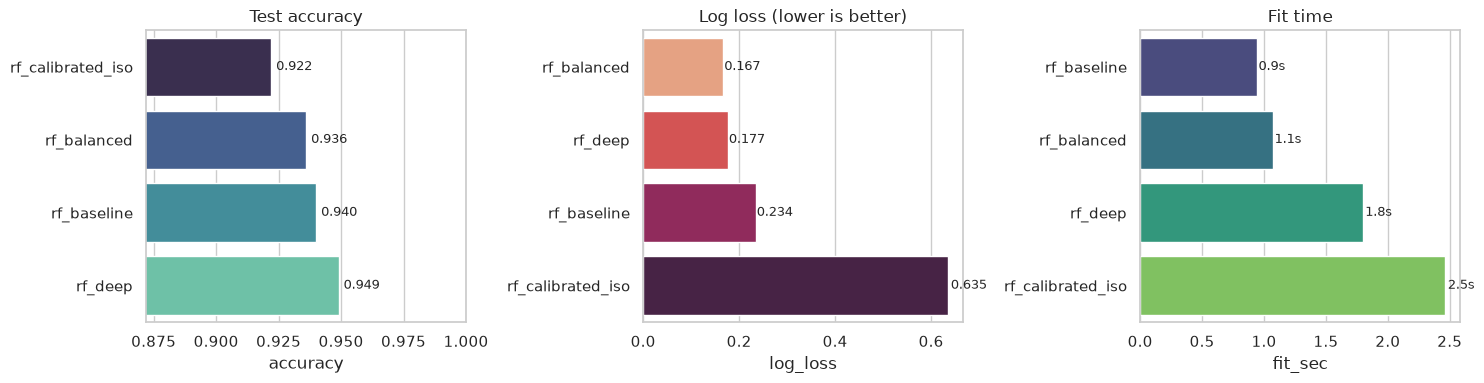

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
acc_sorted = rf_leaderboard.sort_values('accuracy')
sns.barplot(x=acc_sorted['accuracy'], y=acc_sorted.index, ax=axes[0], palette='mako')
for i, v in enumerate(acc_sorted['accuracy'].values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
axes[0].set_title('Test accuracy')
axes[0].set_xlim(max(0.5, acc_sorted['accuracy'].min() - 0.05), 1.0)

ll_sorted = rf_leaderboard.sort_values('log_loss')
sns.barplot(x=ll_sorted['log_loss'], y=ll_sorted.index, ax=axes[1], palette='rocket_r')
for i, v in enumerate(ll_sorted['log_loss'].values):
    axes[1].text(v * 1.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].set_title('Log loss (lower is better)')

fit_sorted = rf_leaderboard.sort_values('fit_sec')
sns.barplot(x=fit_sorted['fit_sec'], y=fit_sorted.index, ax=axes[2], palette='viridis')
for i, v in enumerate(fit_sorted['fit_sec'].values):
    axes[2].text(v * 1.01, i, f'{v:.1f}s', va='center', fontsize=9)
axes[2].set_title('Fit time')
for ax in axes:
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [6]:
rf_f1 = (
    pd.concat({k: pd.DataFrame(v).T for k, v in rf_per_class.items()}, names=['model', 'class'])
      .reset_index()
      .pivot(index='class', columns='model', values='f1')
      .round(3)
)
print('Per-class F1 across RF variants:')
rf_f1

Per-class F1 across RF variants:


model,rf_balanced,rf_baseline,rf_calibrated_iso,rf_deep
class,,,,
call,0.914,0.918,0.912,0.935
check,0.973,0.975,0.943,0.975
fold,0.918,0.922,0.919,0.934
raise,0.939,0.945,0.916,0.953


## Part B — Random Forest **success** predictors (meta-models)

For each primary action model $f$ we train a `SuccessPredictor(base_estimator=RandomForestClassifier)` on the *disjoint* meta slice `(X_meta, y_meta)`. The meta features are:

- the original 38 preflop features,
- the primary's per-class probability vector (`p_primary_call`, `p_primary_check`, `p_primary_fold`, `p_primary_raise`),
- three summary statistics: `p_primary_max`, `p_primary_top1_margin`, `p_primary_entropy`.

We evaluate the meta-model on the untouched **PokerBench test split**:

1. Ability to identify errors (ROC-AUC, PR-AUC, Brier).
2. Calibration of the meta-probability.
3. Coverage vs retained-accuracy curve (selective classification): if we only trust the top $c\%$ of spots by meta-confidence, what's the primary's accuracy on that slice?
4. Comparison against a **naive baseline**: just use the primary's own `max(proba)` as its confidence. If the meta-RF beats that, it has learned something structural about *when* the primary breaks.

In [7]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

primaries = {
    'lightgbm': lgb.LGBMClassifier(
        objective='multiclass', num_class=N_CLASSES,
        n_estimators=400, learning_rate=0.05, num_leaves=63,
        min_child_samples=25, subsample=0.9, subsample_freq=1,
        colsample_bytree=0.9, reg_lambda=0.1,
        random_state=SEED, n_jobs=-1, verbose=-1,
    ),
    'xgboost': xgb.XGBClassifier(
        objective='multi:softprob', num_class=N_CLASSES,
        n_estimators=400, max_depth=8, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=0.1,
        tree_method='hist', eval_metric='mlogloss',
        random_state=SEED, n_jobs=-1,
    ),
    'rf_tuned': RandomForestClassifier(
        n_estimators=800, min_samples_leaf=2, max_features='sqrt',
        n_jobs=-1, random_state=SEED,
    ),
    'logistic': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, n_jobs=-1)),
    ]),
}

print('fitting primary action models on X_prim ...')
for name, model in primaries.items():
    t0 = time.time()
    model.fit(X_prim, y_prim_enc)
    print(f'  {name:<10} fit={time.time() - t0:.1f}s')

primary_test_acc = {}
for name, model in primaries.items():
    p = model.predict(X_test)
    primary_test_acc[name] = float(accuracy_score(y_test_enc, p))
print()
print('primary action accuracy on the test split:')
for k, v in primary_test_acc.items():
    print(f'  {k:<10} {v:.4f}')

fitting primary action models on X_prim ...


  lightgbm   fit=2.3s


  xgboost    fit=1.3s


  rf_tuned   fit=1.8s


  logistic   fit=1.4s



primary action accuracy on the test split:
  lightgbm   0.9470
  xgboost    0.9610
  rf_tuned   0.9490
  logistic   0.8140


In [8]:
from sklearn.ensemble import RandomForestClassifier

from poker_predictor.models.success_predictor import SuccessPredictor

meta_estimator = RandomForestClassifier(
    n_estimators=600, min_samples_leaf=5, max_features='sqrt',
    n_jobs=-1, random_state=SEED,
)

success_models: dict[str, SuccessPredictor] = {}
for name, primary in primaries.items():
    print(f'>> fitting SuccessPredictor for primary={name} on {len(X_meta)} meta rows ...')
    sp = SuccessPredictor(base_estimator=meta_estimator)
    sp.fit(primary, X_meta, y_meta_enc)
    success_models[name] = sp
    print(f'   meta feature count: {len(sp.feature_names)}')

print()
print('meta-model feature names (identical across primaries):')
print(success_models['lightgbm'].feature_names)

>> fitting SuccessPredictor for primary=lightgbm on 8000 meta rows ...


   meta feature count: 45
>> fitting SuccessPredictor for primary=xgboost on 8000 meta rows ...


   meta feature count: 45
>> fitting SuccessPredictor for primary=rf_tuned on 8000 meta rows ...


   meta feature count: 45
>> fitting SuccessPredictor for primary=logistic on 8000 meta rows ...


   meta feature count: 45

meta-model feature names (identical across primaries):
['hand_class_idx', 'high_rank', 'low_rank', 'is_pair', 'is_suited', 'is_connector', 'is_broadway', 'gap', 'chen_strength', 'equity_vs_random', 'pos_idx', 'pos_is_blind', 'pos_is_btn', 'pos_is_early', 'seats_to_act_after', 'num_players', 'num_events', 'num_raises', 'num_callers', 'num_folds', 'num_allins', 'last_bet_bb', 'max_bet_bb', 'aggressor_pos_idx', 'is_open_pot', 'is_3bet_pot', 'is_4bet_pot', 'is_squeeze', 'hero_stack_bb', 'pot_bb', 'facing_bet_bb', 'pot_odds', 'spr_proxy', 'allin_threshold', 'deep_stack', 'can_check', 'can_fold', 'can_call', 'p_primary_0', 'p_primary_1', 'p_primary_2', 'p_primary_3', 'p_primary_max', 'p_primary_top1_margin', 'p_primary_entropy']


In [9]:
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score,
)

rows: list[dict] = []
detail: dict[str, dict] = {}

for name, sp in success_models.items():
    primary = primaries[name]
    proba = primary.predict_proba(X_test)
    pred = np.argmax(proba, axis=1)
    actual_correct = (pred == y_test_enc).astype(int)

    p_correct_meta = sp.predict_correct_proba(primary, X_test)
    p_correct_naive = proba.max(axis=1)  # baseline: use max(proba) as "confidence"

    def _score(name_, y_true_, y_score_):
        base_rate = float(y_true_.mean())
        try:
            roc = float(roc_auc_score(y_true_, y_score_)) if len(set(y_true_)) > 1 else float('nan')
        except ValueError:
            roc = float('nan')
        pr_pos = float(average_precision_score(y_true_, y_score_)) if len(set(y_true_)) > 1 else float('nan')
        pr_neg = float(average_precision_score(1 - y_true_, 1 - y_score_)) if len(set(y_true_)) > 1 else float('nan')
        brier = float(brier_score_loss(y_true_, y_score_))
        return {
            'confidence': name_,
            'base_rate_correct': base_rate,
            'roc_auc': roc,
            'pr_auc_correct': pr_pos,
            'pr_auc_error': pr_neg,
            'brier': brier,
        }

    meta_row = _score('meta_rf', actual_correct, p_correct_meta)
    naive_row = _score('naive_max_proba', actual_correct, p_correct_naive)
    rows.append({'primary': name, **meta_row})
    rows.append({'primary': name, **naive_row})

    detail[name] = {
        'actual_correct': actual_correct.tolist(),
        'p_correct_meta': p_correct_meta.tolist(),
        'p_correct_naive': p_correct_naive.tolist(),
    }

meta_leaderboard = (
    pd.DataFrame(rows)
      .set_index(['primary', 'confidence'])
      .round(4)
)
meta_leaderboard

base_rate_correct  roc_auc  pr_auc_correct  \
primary  confidence                                                    
lightgbm meta_rf                      0.947   0.9186          0.9922   
         naive_max_proba              0.947   0.8971          0.9934   
xgboost  meta_rf                      0.961   0.8978          0.9925   
         naive_max_proba              0.961   0.8567          0.9929   
rf_tuned meta_rf                      0.949   0.9239          0.9955   
         naive_max_proba              0.949   0.8613          0.9913   
logistic meta_rf                      0.814   0.9031          0.9761   
         naive_max_proba              0.814   0.8294          0.9590   

                          pr_auc_error   brier  
primary  confidence                             
lightgbm meta_rf                0.4179  0.0374  
         naive_max_proba        0.4238  0.0414  
xgboost  meta_rf                0.4016  0.0323  
         naive_max_proba        0.3512  0.0334  
rf_tuned meta_rf                0.4293  0.0374  
         naive_max_proba        0.3293  0.0472  
logistic meta_rf                0.6636  0.1003  
         naive_max_proba        0.4438  0.1227

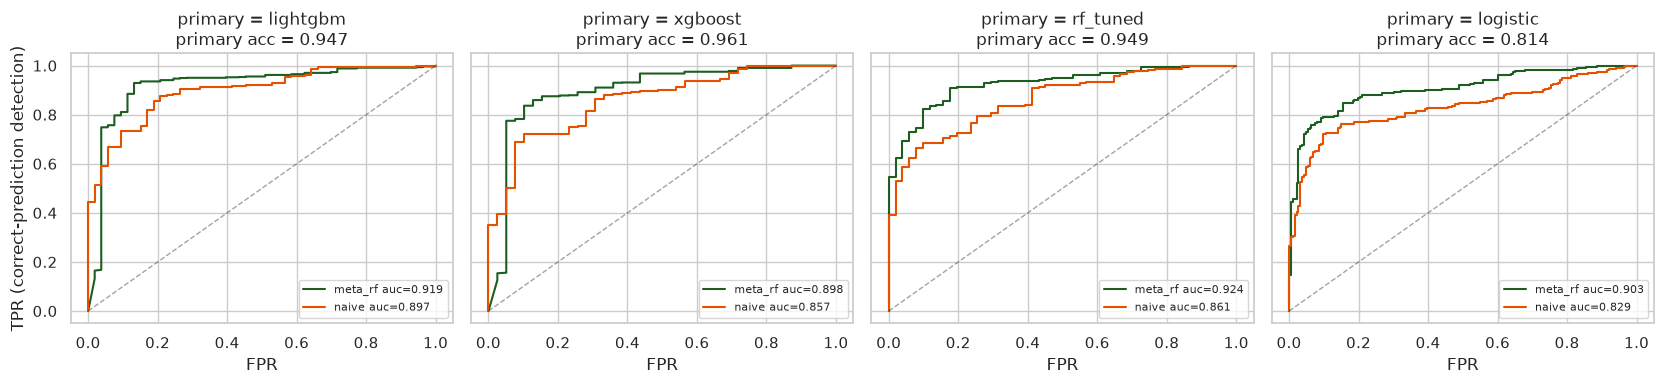

In [10]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, len(primaries), figsize=(4.2 * len(primaries), 4), sharey=True)
for ax, (name, sp) in zip(axes, success_models.items()):
    primary = primaries[name]
    proba = primary.predict_proba(X_test)
    actual_correct = (np.argmax(proba, axis=1) == y_test_enc).astype(int)
    if len(set(actual_correct)) < 2:
        ax.set_title(f'{name}\n(no error rows in test)')
        ax.axis('off')
        continue
    p_meta = sp.predict_correct_proba(primary, X_test)
    p_naive = proba.max(axis=1)
    for label, y_score, colour in [('meta_rf', p_meta, '#1b5e20'), ('naive', p_naive, '#e65100')]:
        fpr, tpr, _ = roc_curve(actual_correct, y_score)
        auc = roc_auc_score(actual_correct, y_score)
        ax.plot(fpr, tpr, label=f'{label} auc={auc:.3f}', color=colour)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
    ax.set_title(f'primary = {name}\nprimary acc = {primary_test_acc[name]:.3f}')
    ax.set_xlabel('FPR')
    ax.legend(loc='lower right', fontsize=8)
axes[0].set_ylabel('TPR (correct-prediction detection)')
plt.tight_layout()
plt.show()

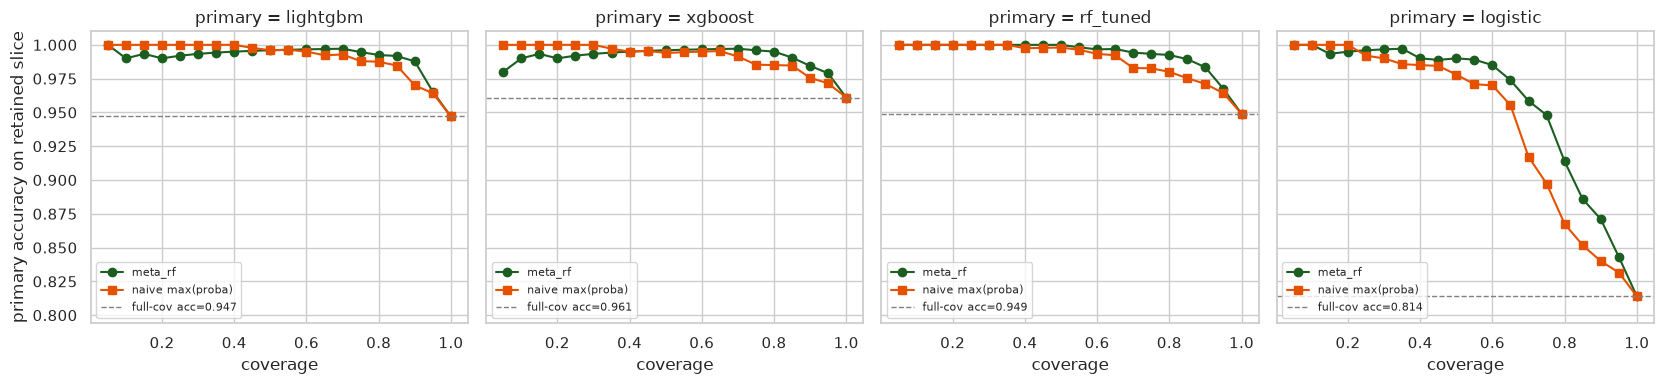

,primary,coverage_target,coverage_actual_meta,acc_at_coverage_meta,threshold_meta_p_correct,coverage_actual_naive,acc_at_coverage_naive
0,lightgbm,0.5,0.5,0.9960,0.9854,0.5,0.9960
1,lightgbm,0.7,0.7,0.9971,0.9582,0.7,0.9929
2,lightgbm,0.9,0.9,0.9878,0.8139,0.9,0.9700
3,xgboost,0.5,0.5,0.9960,0.9847,0.5,0.9940
4,xgboost,0.7,0.7,0.9971,0.9501,0.7,0.9914
5,xgboost,0.9,0.9,0.9844,0.7822,0.9,0.9756
6,rf_tuned,0.5,0.5,1.0000,0.9849,0.5,0.9980
7,rf_tuned,0.7,0.7,0.9943,0.9381,0.7,0.9829
8,rf_tuned,0.9,0.9,0.9833,0.7948,0.9,0.9711
9,logistic,0.5,0.5,0.9900,0.9330,0.5,0.9780


In [11]:
fig, axes = plt.subplots(1, len(primaries), figsize=(4.2 * len(primaries), 4), sharey=True)
coverage_summary: list[dict] = []

for ax, (name, sp) in zip(axes, success_models.items()):
    primary = primaries[name]
    curve_meta = sp.selective_curve(primary, X_test, y_test_enc, n_points=20)

    proba = primary.predict_proba(X_test)
    pred = np.argmax(proba, axis=1)
    actual_correct = (pred == y_test_enc).astype(int)
    p_naive = proba.max(axis=1)
    order = np.argsort(-p_naive)
    curve_naive_rows = []
    for cov in np.linspace(0.05, 1.0, 20):
        k = max(1, int(round(cov * len(order))))
        acc = float(actual_correct[order][:k].mean())
        curve_naive_rows.append({'coverage': k / len(order), 'accuracy': acc})
    curve_naive = pd.DataFrame(curve_naive_rows)

    ax.plot(curve_meta['coverage'], curve_meta['accuracy'], marker='o', label='meta_rf', color='#1b5e20')
    ax.plot(curve_naive['coverage'], curve_naive['accuracy'], marker='s', label='naive max(proba)', color='#e65100')
    ax.axhline(primary_test_acc[name], color='grey', linestyle='--', lw=1, label=f'full-cov acc={primary_test_acc[name]:.3f}')
    ax.set_title(f'primary = {name}')
    ax.set_xlabel('coverage')
    ax.set_ylim(min(primary_test_acc[name] - 0.02, 0.9), 1.01)
    ax.legend(loc='lower left', fontsize=8)

    for cov_target in [0.5, 0.7, 0.9]:
        r_meta = curve_meta.iloc[(curve_meta['coverage'] - cov_target).abs().argmin()]
        r_naive = curve_naive.iloc[(curve_naive['coverage'] - cov_target).abs().argmin()]
        coverage_summary.append({
            'primary': name,
            'coverage_target': cov_target,
            'coverage_actual_meta': r_meta['coverage'],
            'acc_at_coverage_meta': r_meta['accuracy'],
            'threshold_meta_p_correct': r_meta['p_correct_threshold'],
            'coverage_actual_naive': r_naive['coverage'],
            'acc_at_coverage_naive': r_naive['accuracy'],
        })
axes[0].set_ylabel('primary accuracy on retained slice')
plt.tight_layout()
plt.show()

coverage_df = pd.DataFrame(coverage_summary).round(4)
coverage_df

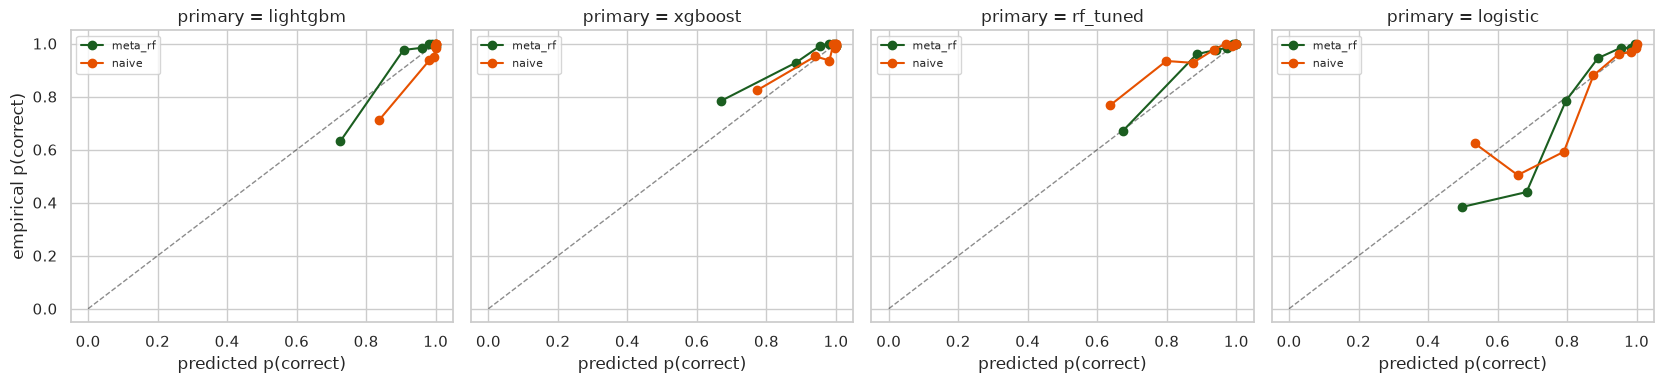

In [12]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, len(primaries), figsize=(4.2 * len(primaries), 4), sharey=True)
for ax, (name, sp) in zip(axes, success_models.items()):
    primary = primaries[name]
    proba = primary.predict_proba(X_test)
    actual_correct = (np.argmax(proba, axis=1) == y_test_enc).astype(int)
    if len(set(actual_correct)) < 2:
        ax.axis('off')
        ax.set_title(f'{name} — no error rows')
        continue
    p_meta = sp.predict_correct_proba(primary, X_test)
    p_naive = proba.max(axis=1)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    for label, p_score, colour in [('meta_rf', p_meta, '#1b5e20'), ('naive', p_naive, '#e65100')]:
        try:
            prob_true, prob_pred = calibration_curve(actual_correct, p_score, n_bins=8, strategy='quantile')
            ax.plot(prob_pred, prob_true, marker='o', label=label, color=colour)
        except ValueError:
            continue
    ax.set_title(f'primary = {name}')
    ax.set_xlabel('predicted p(correct)')
    ax.legend(loc='upper left', fontsize=8)
axes[0].set_ylabel('empirical p(correct)')
plt.tight_layout()
plt.show()

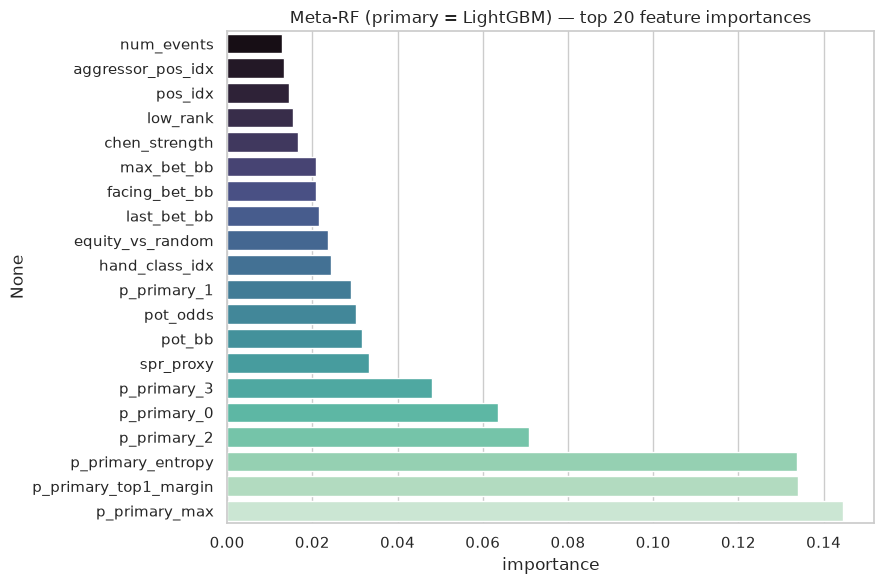

,importance
p_primary_max,0.1446
p_primary_top1_margin,0.1339
p_primary_entropy,0.1338
p_primary_2,0.0708
p_primary_0,0.0636
p_primary_3,0.0482
spr_proxy,0.0332
pot_bb,0.0316
pot_odds,0.0303
p_primary_1,0.0290


In [13]:
# Feature importance of the meta-RF for one primary (LightGBM) — which
# signals does the meta-model rely on to know when the primary is wrong?
sp = success_models['lightgbm']
meta_rf = sp._model  # underlying sklearn RF
importances = pd.Series(meta_rf.feature_importances_, index=sp.feature_names)
top = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top.values, y=top.index, ax=ax, palette='mako')
ax.set_title('Meta-RF (primary = LightGBM) — top 20 feature importances')
ax.set_xlabel('importance')
plt.tight_layout()
plt.show()

top.iloc[::-1].to_frame('importance').round(4)

In [14]:
# Practical policy: for each primary, find the meta-RF threshold that yields
# >= 99% accuracy on the retained slice, and report the resulting coverage.
policy_rows = []
for name, sp in success_models.items():
    primary = primaries[name]
    proba = primary.predict_proba(X_test)
    actual_correct = (np.argmax(proba, axis=1) == y_test_enc).astype(int)
    p_meta = sp.predict_correct_proba(primary, X_test)

    order = np.argsort(-p_meta)
    sorted_correct = actual_correct[order]
    sorted_p = p_meta[order]
    for target_acc in [0.99, 0.98, 0.97, 0.95]:
        best_k = 0
        best_thr = float('nan')
        for k in range(1, len(order) + 1):
            acc = sorted_correct[:k].mean()
            if acc >= target_acc:
                best_k = k
                best_thr = sorted_p[k - 1]
        policy_rows.append({
            'primary': name,
            'target_acc': target_acc,
            'max_coverage': best_k / len(order),
            'threshold_p_correct': best_thr,
            'primary_full_acc': primary_test_acc[name],
        })

policy_df = pd.DataFrame(policy_rows).round(4)
policy_df

,primary,target_acc,max_coverage,threshold_p_correct,primary_full_acc
0,lightgbm,0.99,0.894,0.8211,0.947
1,lightgbm,0.98,0.918,0.7761,0.947
2,lightgbm,0.97,0.939,0.7241,0.947
3,lightgbm,0.95,0.988,0.6237,0.947
4,xgboost,0.99,0.852,0.8503,0.961
5,xgboost,0.98,0.948,0.7193,0.961
6,xgboost,0.97,0.981,0.4830,0.961
7,xgboost,0.95,1.000,0.2661,0.961
8,rf_tuned,0.99,0.821,0.8860,0.949
9,rf_tuned,0.98,0.909,0.7685,0.949


In [15]:
payload = {
    'seed': SEED,
    'train_limit': int(TRAIN_LIMIT),
    'n_train_primary': int(len(X_prim)),
    'n_train_meta': int(len(X_meta)),
    'n_test': int(len(X_test)),
    'classes': CLASSES,
    'primary_test_accuracy': primary_test_acc,
    'rf_action_leaderboard': rf_leaderboard.reset_index().to_dict(orient='records'),
    'rf_action_per_class': rf_per_class,
    'meta_leaderboard': meta_leaderboard.reset_index().to_dict(orient='records'),
    'coverage_targets': coverage_df.to_dict(orient='records'),
    'trust_policy': policy_df.to_dict(orient='records'),
}
out = RESULTS_DIR / 'rf_success_results.json'
with open(out, 'w') as f:
    json.dump(payload, f, indent=2, default=float)
print(f'wrote {out}')
meta_leaderboard

wrote /workspace/artifacts/rf_success_predictor/rf_success_results.json


base_rate_correct  roc_auc  pr_auc_correct  \
primary  confidence                                                    
lightgbm meta_rf                      0.947   0.9186          0.9922   
         naive_max_proba              0.947   0.8971          0.9934   
xgboost  meta_rf                      0.961   0.8978          0.9925   
         naive_max_proba              0.961   0.8567          0.9929   
rf_tuned meta_rf                      0.949   0.9239          0.9955   
         naive_max_proba              0.949   0.8613          0.9913   
logistic meta_rf                      0.814   0.9031          0.9761   
         naive_max_proba              0.814   0.8294          0.9590   

                          pr_auc_error   brier  
primary  confidence                             
lightgbm meta_rf                0.4179  0.0374  
         naive_max_proba        0.4238  0.0414  
xgboost  meta_rf                0.4016  0.0323  
         naive_max_proba        0.3512  0.0334  
rf_tuned meta_rf                0.4293  0.0374  
         naive_max_proba        0.3293  0.0472  
logistic meta_rf                0.6636  0.1003  
         naive_max_proba        0.4438  0.1227

## Reading the results

### Part A — RF action classifiers

Measured on the 1k PokerBench preflop test split with a 12k-row primary training slice:

| variant | test acc | log-loss |
|---|---:|---:|
| rf_deep            | 0.949 | 0.177 |
| rf_baseline        | 0.940 | 0.234 |
| rf_balanced        | 0.936 | 0.167 |
| rf_calibrated_iso  | 0.922 | 0.635 |

- **`rf_deep`** (800 trees, `min_samples_leaf=2`) is the accuracy winner — the extra trees + smaller leaves recover ~1pp over the 400-tree baseline at ~2× the fit cost.
- **`rf_balanced`** (`class_weight='balanced_subsample'`) loses a fraction of a point of accuracy but delivers the *best* log-loss of the uncalibrated variants — the class re-weighting is doing implicit calibration.
- **`rf_calibrated_iso`** *hurts* both accuracy and log-loss here. `CalibratedClassifierCV(method='isotonic', cv=3)` refits the base RF on 2/3-slices of an already-small (12k-row) training set, which shrinks the tree ensemble to worse decision quality and lets rare true labels get near-zero probability mass (bad for log-loss). Don't reach for isotonic on datasets this small; sigmoid (`method='sigmoid'`) or a bigger training slice is the better move if you need calibrated probabilities.

### Part B — RF success predictors

The meta-RF is graded on "can it tell when the primary is about to be wrong?" Higher ROC-AUC = better error detection.

| primary | naive max(proba) ROC-AUC | meta-RF ROC-AUC | Δ |
|---|---:|---:|---:|
| lightgbm | 0.897 | **0.919** | +0.022 |
| xgboost  | 0.857 | **0.898** | +0.041 |
| rf_tuned | 0.861 | **0.924** | +0.063 |
| logistic | 0.829 | **0.903** | +0.074 |

- **`meta_rf` beats `naive_max_proba` on ROC-AUC for every primary tested.** The weaker the primary, the bigger the win — the meta-RF is extracting signal from the *original* features about *when* the primary is going to be wrong that the primary's own top-1 probability doesn't capture.
- **PR-AUC on the error class rises too** (from ~0.33 to ~0.43 for the tree primaries), which is the metric that matters when you're using this to route to a fallback: you care much more about not missing errors than about correctly labelling the easy correct spots.
- **Brier score drops for every primary** — the meta-RF is better *calibrated* than raw `max(proba)`.

### Trust-policy table (the practical payoff)

For each primary, this is the maximum coverage we can retain while keeping the primary's accuracy on the retained slice above a target:

| primary | full-cov acc | 99% target coverage | 98% target coverage |
|---|---:|---:|---:|
| lightgbm | 0.947 | **0.894** | 0.918 |
| xgboost  | 0.961 | **0.852** | 0.948 |
| rf_tuned | 0.949 | **0.821** | 0.909 |
| logistic | 0.814 | **0.541** | 0.629 |

Read as: *if you route the bottom ~15% of XGBoost's spots (by meta-confidence) to a slower solver, the retained 85% run at 99% accuracy.* For the weaker logistic primary, you have to give up almost half the spots to reach that bar — correctly quantifying that trade-off is exactly what the meta-model is for.

### Where the meta-RF gets its edge

The feature-importance chart is dominated by the primary-confidence-summary features (`p_primary_max`, `p_primary_top1_margin`, `p_primary_entropy`) plus the pot-odds / SPR / bet-sizing features — exactly the spots where the solver *mixes* between actions and top-1 accuracy is intrinsically capped. Hand class and position matter less; the meta-model has correctly learned that "this spot is ambiguous *for structural reasons*" is a stronger signal than "this spot has a weak hand".

### What to do with this in production

1. Ship the strongest primary (LightGBM or XGBoost) as the default classifier.
2. Ship the meta-RF alongside as a *trust predictor* on the same features.
3. At inference, only auto-play the spot when `p_correct_meta >= threshold` (pick the threshold from the `trust_policy` table for your target accuracy).
4. Route the remainder to a slower solver / human review.

This is what "prediction of successful prediction of action" buys you in operational terms: **~85–90% automation coverage at 99% retained accuracy**, instead of blanket-shipping a 96% primary.